# Calories Burnt Prediction using Machine Learning

## Objective
The goal of this project is to predict the number of calories burned during exercise based on features such as age, gender, duration, heart rate, and body temperature.

This is a regression problem where the model predicts a continuous value.

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

## Data Collection and Processing

In [106]:
calories = pd.read_csv("data/calories.csv")

In [107]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [108]:
exercise_data = pd.read_csv("data/exercise.csv")

In [109]:
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


## Data Merging

Two datasets (exercise data and calories data) are combined using a common identifier.

This ensures that each exercise record is linked with the corresponding calories burned.

In [110]:
calories_data = pd.concat([exercise_data,calories['Calories']],axis=1)

In [111]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


## Dataset Description

The dataset contains information about individuals and their exercise sessions.

Important features include:

- Age
- Gender
- Height
- Weight
- Duration of exercise
- Heart Rate
- Body Temperature

Target variable:
- Calories burned

In [112]:
calories_data.shape

(15000, 9)

In [113]:
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [114]:
calories_data.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


## Exploratory Data Analysis

In [115]:
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


## Data Visualization

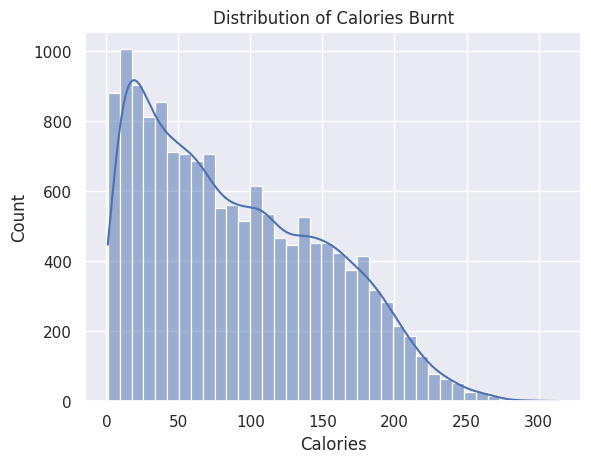

In [138]:
sns.histplot(calories_data['Calories'], kde=True)
plt.title("Distribution of Calories Burnt")

In [116]:
sns.set()

In [117]:
calories_data['Gender'].value_counts()

,count
Gender,
female,7553
male,7447


<Axes: xlabel='Gender', ylabel='count'>

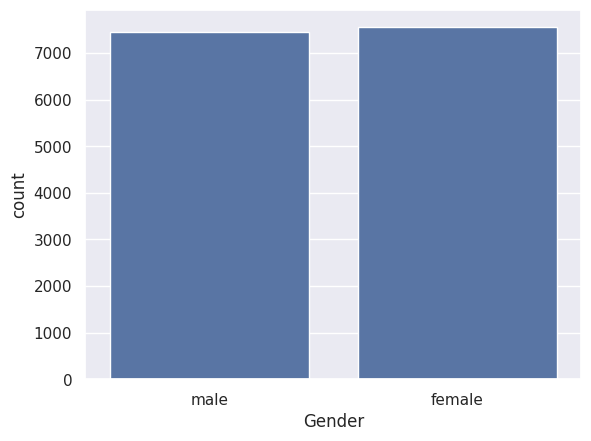

In [118]:
# plotting the gender column in countplot
sns.countplot(x='Gender',data = calories_data)

/tmp/ipykernel_1929/1592373977.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

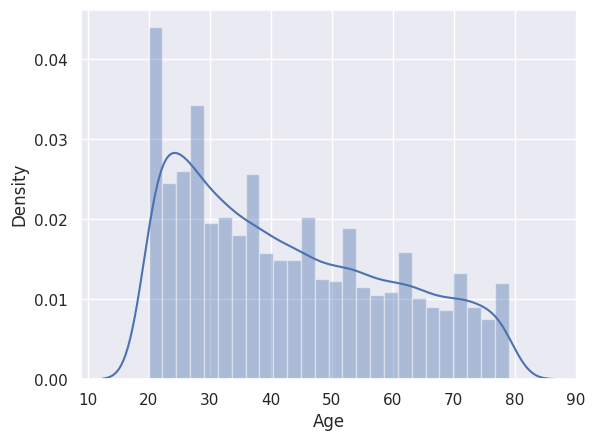

In [119]:
# plotting the age column
sns.distplot(calories_data['Age'])

/tmp/ipykernel_1929/2430521470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Height'])


<Axes: xlabel='Height', ylabel='Density'>

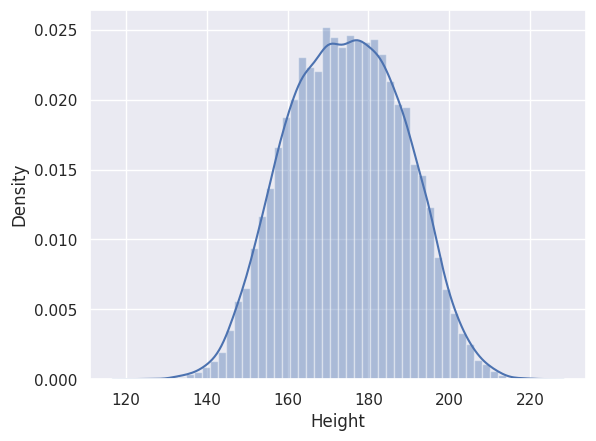

In [120]:
sns.distplot(calories_data['Height'])

/tmp/ipykernel_1929/1539919118.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

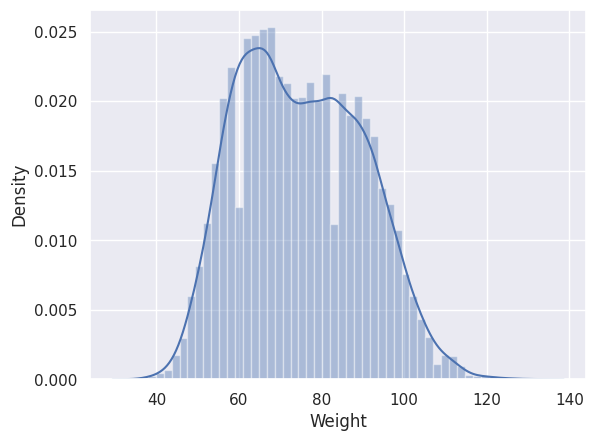

In [121]:
sns.distplot(calories_data['Weight'])

## Correlation Analysis

In [122]:
correlation = calories_data.corr(numeric_only=True)

<Axes: >

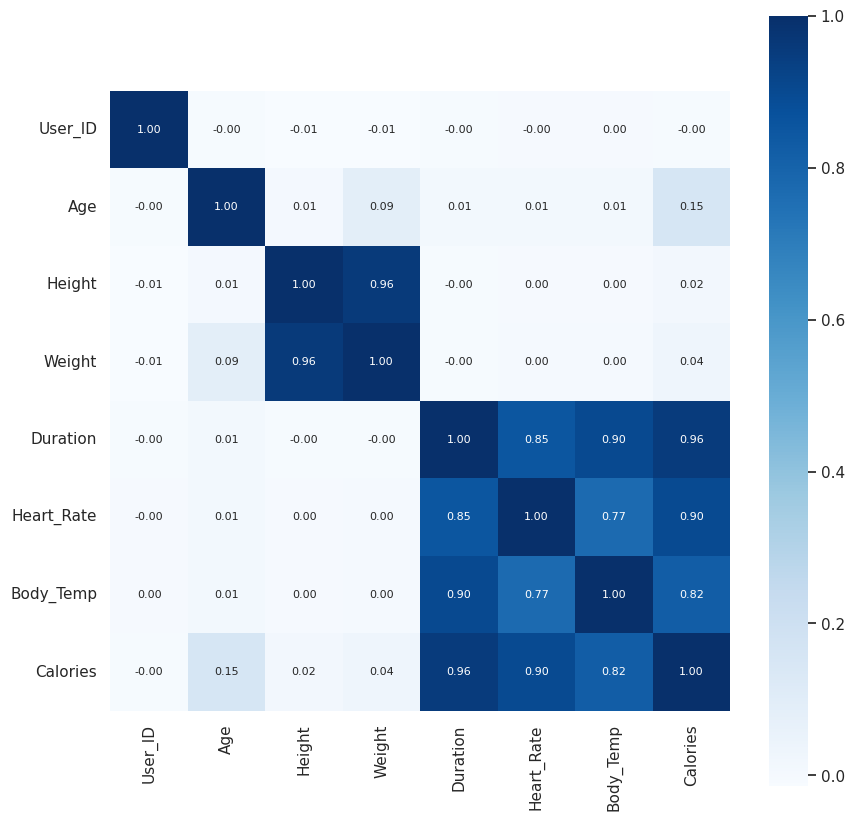

In [123]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.2f',annot=True,annot_kws={'size':8},cmap='Blues')

In [124]:
calories_data.replace({"Gender":{"male":0,"female":1}},inplace=True)

/tmp/ipykernel_1929/2986323065.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data.replace({"Gender":{"male":0,"female":1}},inplace=True)


In [125]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


## Splitting Features and Target

`X` contains the input variables used for prediction.

`Y` contains the target variable: calories burned.

In [126]:
X = calories_data.drop(columns=["User_ID","Calories"],axis=1)
Y = calories_data['Calories']

In [127]:
print("Feature shape:", X.shape)
print("Target shape:", Y.shape)

Feature shape: (15000, 7)
Target shape: (15000,)


In [128]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [129]:
print(X.shape,X_train.shape,X_test.shape)

(15000, 7) (12000, 7) (3000, 7)


## Model Training

In [130]:
model = XGBRegressor()

In [131]:
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [132]:
test_data_prediction = model.predict(X_test)

## Model Evaluation

We evaluate the regression model using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

In [133]:
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)
mse = metrics.mean_squared_error(Y_test, test_data_prediction)
r2 = metrics.r2_score(Y_test, test_data_prediction)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Absolute Error: 1.4833678883314132
Mean Squared Error: 4.710710012461346
R2 Score: 0.998800624504713


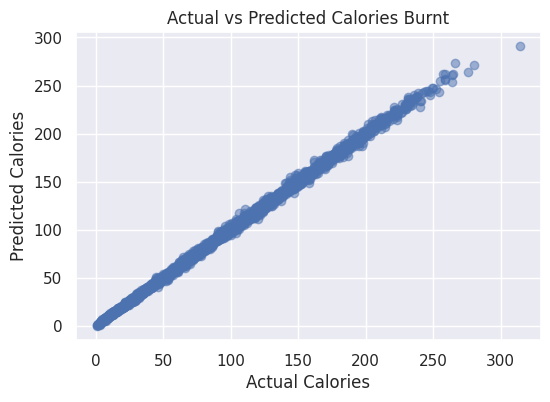

In [137]:
plt.figure(figsize=(6,4))
plt.scatter(Y_test, test_data_prediction, alpha=0.5)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories Burnt")

plt.show()

In [134]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
4,Duration,0.899050
5,Heart_Rate,0.046049
0,Gender,0.026830
1,Age,0.022189
3,Weight,0.005494
2,Height,0.000227
6,Body_Temp,0.000161


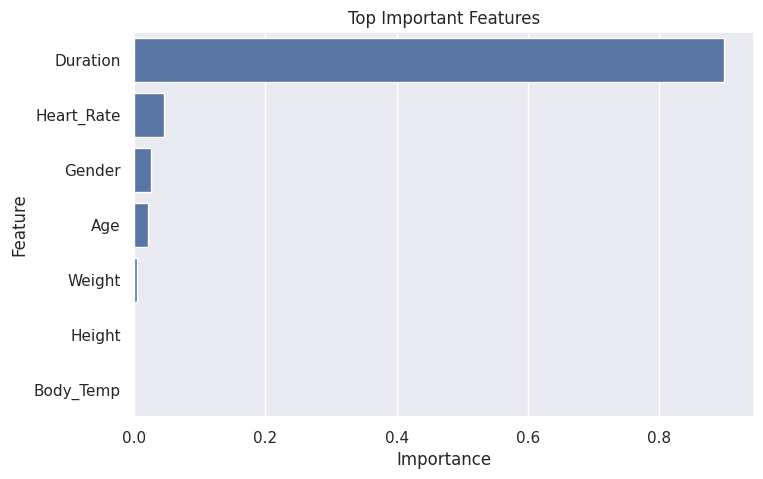

In [135]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top Important Features")
plt.show()

### Model Interpretation

The model predicts calories burned with good accuracy.

Features such as duration, heart rate, and body temperature have strong influence on calorie expenditure.

Some variation exists due to individual differences in metabolism.

## Conclusion

This project predicts calories burned during exercise using machine learning.

Key observations:

- duration of exercise strongly impacts calories burned  
- heart rate is an important indicator of energy expenditure  
- body temperature correlates with workout intensity  

Future improvements:

- try deep learning models  
- collect more personalized data  
- deploy as a fitness tracking tool  